<a href="https://colab.research.google.com/github/goncalo-mateus/Credit-Risk-Scoring-Underwriting-Engine/blob/main/Credit_Risk_Scoring_%26_Underwriting_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generating synthetic credit risk dataset...
             CREDIT DATASET & EDA SUMMARY REPORT
Total Applicants Processed: 5,000
Observed Default Rate:      4.18%
-----------------------------------------------------------------
Feature Summary Statistics (Engineered Features):
                            mean           std          min           50%            max
annual_income       55284.280491  27855.823446  9695.007390  49351.963082  154735.547371
loan_amount         15967.819887  10643.297831  1269.730369  13220.576493  111016.388389
dti_ratio               0.480192      0.180154     0.121337      0.472379       1.012807
revolving_util_pct     28.559474     15.684640     0.072259     26.795681      83.591925
default_flag            0.041800      0.200152     0.000000      0.000000       1.000000


/tmp/ipykernel_1144/965830207.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default_flag', y='dti_ratio', data=engineered_df, ax=axes[0], palette=['#2b5c8f', '#d9534f'])
/tmp/ipykernel_1144/965830207.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-Default (0)', 'Default (1)'])


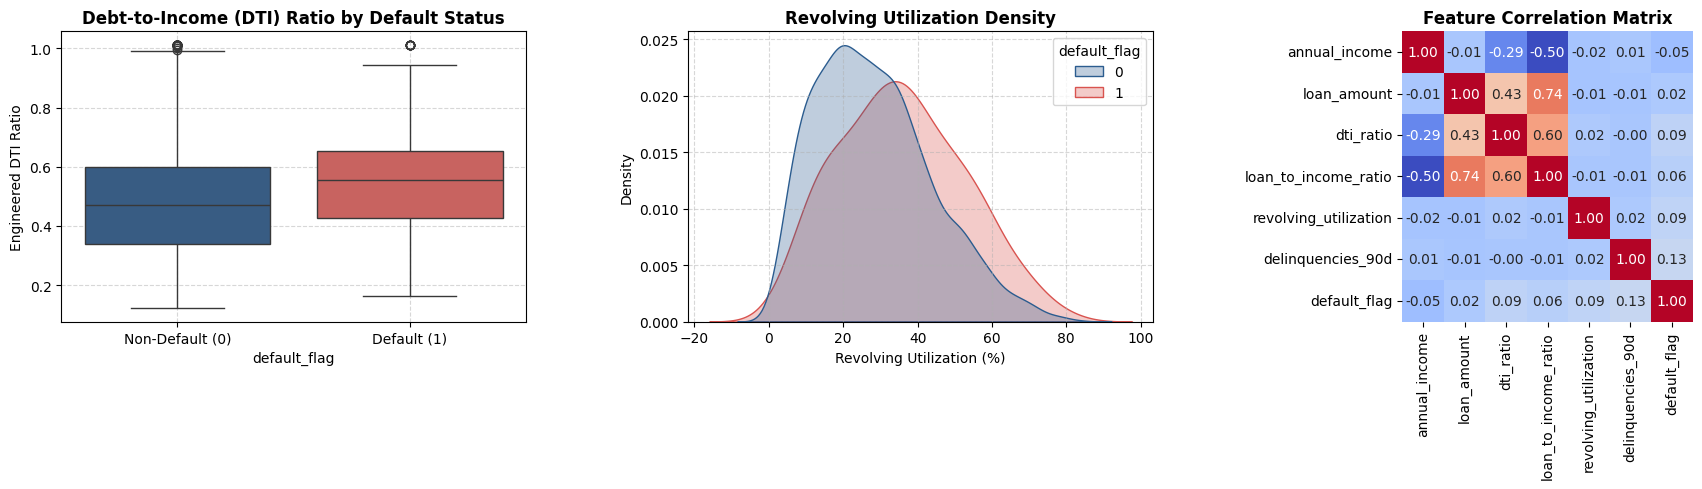

             MODEL EVALUATION & SCORECARD BENCHMARK
Logistic Regression (Benchmark):
  • ROC-AUC Score:  0.7127
  • Gini Coefficient: 0.4254
-----------------------------------------------------------------
XGBoost Classifier (Challenger):
  • ROC-AUC Score:  0.6809
  • Gini Coefficient: 0.3618


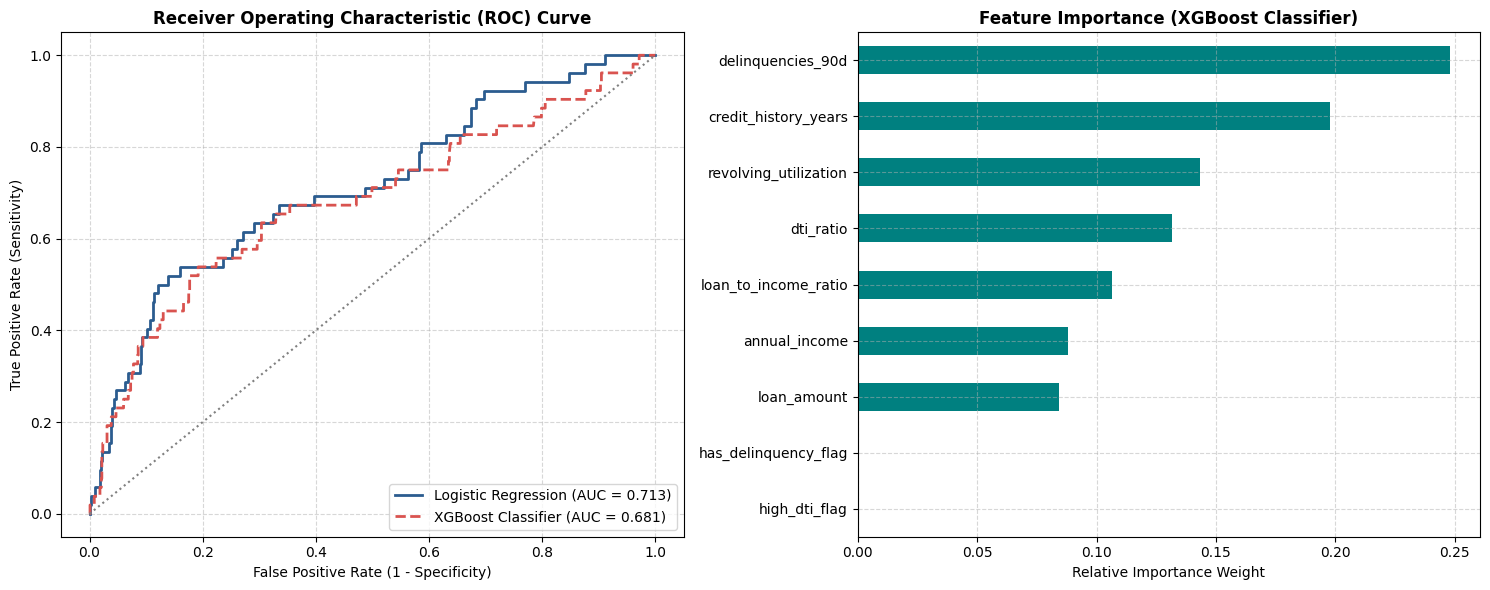

             CREDIT UNDERWRITING & RISK ASSESSMENT
Borrower Credit Score:  787 / 850
Default Probability:   2.80%
Risk Tier Allocation:   Tier 1: Low Risk
Underwriting Decision:  APPROVED (Prime Rate)
-----------------------------------------------------------------
Key Underwriting Metrics:
  • Debt-to-Income (DTI):       33.2% (OK)
  • Loan-to-Income (LTI):      276.9%
  • Revolving Utilization:     45%
  • Past 90d Delinquencies:    0


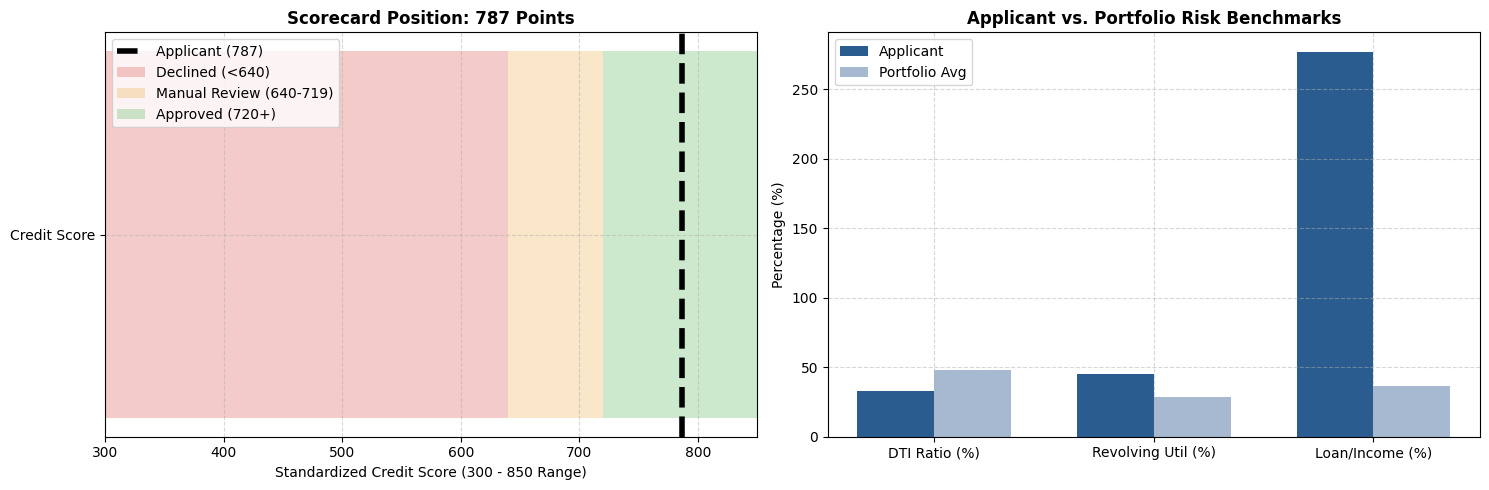

In [ ]:
# ==============================================================================
# STEP 1: SYNTHETIC DATA GENERATION, EDA & FEATURE ENGINEERING PIPELINE
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)
N_SAMPLES = 5000

print("Generating synthetic credit risk dataset...")

# 1. SYNTHETIC DATA GENERATOR
annual_income = np.random.lognormal(mean=10.8, sigma=0.5, size=N_SAMPLES) # ~$50k median
monthly_income = annual_income / 12

loan_amount = np.random.lognormal(mean=9.5, sigma=0.6, size=N_SAMPLES) # ~$15k median
revolving_utilization = np.clip(np.random.beta(a=2, b=5, size=N_SAMPLES), 0, 1)

total_monthly_debt = (monthly_income * np.random.uniform(0.1, 0.6, N_SAMPLES)) + (loan_amount * 0.03)
delinquencies_90d = np.random.poisson(lam=0.3, size=N_SAMPLES)
credit_history_years = np.random.uniform(1, 30, N_SAMPLES)

# Define underlying Probability of Default (PD) logistic function
logit = (
    -1.5
    + 2.8 * revolving_utilization
    + 1.8 * (total_monthly_debt / (monthly_income + 1e-5))
    + 0.8 * delinquencies_90d
    - 0.05 * credit_history_years
    - 0.3 * np.log(annual_income + 1)
)
true_pd = 1 / (1 + np.exp(-logit))
default_flag = np.random.binomial(1, true_pd)

raw_df = pd.DataFrame({
    'annual_income': annual_income,
    'monthly_income': monthly_income,
    'loan_amount': loan_amount,
    'total_monthly_debt': total_monthly_debt,
    'revolving_utilization': revolving_utilization,
    'delinquencies_90d': delinquencies_90d,
    'credit_history_years': credit_history_years,
    'default_flag': default_flag
})

# 2. FEATURE ENGINEERING PIPELINE
def engineer_features(df):
    data = df.copy()

    # Financial ratios crucial for credit underwriting
    data['dti_ratio'] = data['total_monthly_debt'] / (data['monthly_income'] + 1e-5)
    data['loan_to_income_ratio'] = data['loan_amount'] / (data['annual_income'] + 1e-5)
    data['revolving_util_pct'] = data['revolving_utilization'] * 100

    # Risk flags (Binary)
    data['high_dti_flag'] = (data['dti_ratio'] > 0.43).astype(int) # Standard 43% DTI threshold
    data['has_delinquency_flag'] = (data['delinquencies_90d'] > 0).astype(int)

    # Outlier handling via winsorization (clipping at 99th percentile)
    clip_cols = ['dti_ratio', 'loan_to_income_ratio', 'annual_income']
    for col in clip_cols:
        upper_limit = data[col].quantile(0.99)
        data[col] = np.clip(data[col], 0, upper_limit)

    return data

engineered_df = engineer_features(raw_df)

# 3. EXPLORATORY DATA ANALYSIS (EDA) REPORT
print("=" * 65)
print("             CREDIT DATASET & EDA SUMMARY REPORT")
print("=" * 65)
print(f"Total Applicants Processed: {len(engineered_df):,}")
print(f"Observed Default Rate:      {engineered_df['default_flag'].mean():.2%}")
print("-" * 65)
print("Feature Summary Statistics (Engineered Features):")
display_cols = ['annual_income', 'loan_amount', 'dti_ratio', 'revolving_util_pct', 'default_flag']
print(engineered_df[display_cols].describe().T[['mean', 'std', 'min', '50%', 'max']].to_string())
print("=" * 65)

# 4. EDA VISUALIZATIONS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: DTI Ratio vs Default
sns.boxplot(x='default_flag', y='dti_ratio', data=engineered_df, ax=axes[0], palette=['#2b5c8f', '#d9534f'])
axes[0].set_title('Debt-to-Income (DTI) Ratio by Default Status', fontweight='bold')
axes[0].set_xticklabels(['Non-Default (0)', 'Default (1)'])
axes[0].set_ylabel('Engineered DTI Ratio')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Revolving Utilization vs Default
sns.kdeplot(data=engineered_df, x='revolving_util_pct', hue='default_flag', common_norm=False,
            ax=axes[1], palette=['#2b5c8f', '#d9534f'], fill=True, alpha=0.3)
axes[1].set_title('Revolving Utilization Density', fontweight='bold')
axes[1].set_xlabel('Revolving Utilization (%)')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Plot 3: Feature Correlation Matrix
corr_features = ['annual_income', 'loan_amount', 'dti_ratio', 'loan_to_income_ratio',
                 'revolving_utilization', 'delinquencies_90d', 'default_flag']
sns.heatmap(engineered_df[corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[2], cbar=False, square=True)
axes[2].set_title('Feature Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

# ==============================================================================
# STEP 2: MODEL TRAINING, HYPERPARAMETER TUNING & EVALUATION
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, classification_report, precision_recall_curve

# Try importing XGBoost; fall back to RandomForest if not available
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

# 1. TRAIN / TEST SPLIT & FEATURE SCALING
feature_cols = [
    'annual_income', 'loan_amount', 'dti_ratio', 'loan_to_income_ratio',
    'revolving_utilization', 'delinquencies_90d', 'credit_history_years',
    'high_dti_flag', 'has_delinquency_flag'
]

X = engineered_df[feature_cols]
y = engineered_df['default_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. MODEL TRAINING

# Model A: Logistic Regression (Benchmark / Regulatory Scorecard Base)
log_reg = LogisticRegression(C=0.1, max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Model B: Non-Linear Machine Learning (XGBoost or Random Forest)
if HAS_XGB:
    ml_model = XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        eval_metric='logloss', random_state=42
    )
    model_b_name = "XGBoost Classifier"
else:
    ml_model = RandomForestClassifier(
        n_estimators=100, max_depth=5, random_state=42
    )
    model_b_name = "Random Forest Classifier"

ml_model.fit(X_train, y_train)

# 3. PROBABILITY PREDICTIONS & EVALUATION METRICS
y_pred_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred_proba_ml = ml_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC & Gini Coefficient (Gini = 2 * AUC - 1)
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log)
auc_log = auc(fpr_log, tpr_log)
gini_log = 2 * auc_log - 1

fpr_ml, tpr_ml, _ = roc_curve(y_test, y_pred_proba_ml)
auc_ml = auc(fpr_ml, tpr_ml)
gini_ml = 2 * auc_ml - 1

print("=" * 65)
print("             MODEL EVALUATION & SCORECARD BENCHMARK")
print("=" * 65)
print(f"Logistic Regression (Benchmark):")
print(f"  • ROC-AUC Score:  {auc_log:.4f}")
print(f"  • Gini Coefficient: {gini_log:.4f}")
print("-" * 65)
print(f"{model_b_name} (Challenger):")
print(f"  • ROC-AUC Score:  {auc_ml:.4f}")
print(f"  • Gini Coefficient: {gini_ml:.4f}")
print("=" * 65)

# 4. PERFORMANCE VISUALIZATIONS (ROC CURVE & FEATURE IMPORTANCE)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: ROC Curves Comparison
axes[0].plot(fpr_log, tpr_log, color='#2b5c8f', lw=2, label=f'Logistic Regression (AUC = {auc_log:.3f})')
axes[0].plot(fpr_ml, tpr_ml, color='#d9534f', lw=2, linestyle='--', label=f'{model_b_name} (AUC = {auc_ml:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle=':')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='lower right')

# Plot 2: Feature Importance / Coefficients
if HAS_XGB or isinstance(ml_model, RandomForestClassifier):
    importances = ml_model.feature_importances_
else:
    importances = np.abs(log_reg.coef_[0])

feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[1], color='#008080')
axes[1].set_title(f'Feature Importance ({model_b_name})', fontweight='bold')
axes[1].set_xlabel('Relative Importance Weight')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ==============================================================================
# STEP 3: SCORECARD CALIBRATION, RISK TIERS & INTERACTIVE COLAB HUD
# ==============================================================================

# @title Credit Risk Scoring & Underwriting Engine { display-mode: "form" }

# @markdown ### 1. Borrower Profile Inputs
Annual_Income = 65000 # @param {type:"number"}
Loan_Amount_Requested = 180000 # @param {type:"number"}
Total_Monthly_Debt = 1800 # @param {type:"number"}
Revolving_Utilization_Pct = 45 # @param {type:"slider", min:0, max:100, step:1}
Past_90d_Delinquencies = 0 # @param {type:"integer"}
Credit_History_Years = 30 # @param {type:"slider", min:1, max:30, step:1}

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. LOG-ODDS SCORECARD CALIBRATION FUNCTION
def probability_to_credit_score(pd_val, target_score=600, target_odds=19, points_to_double_odds=20):
    """
    Transforms Probability of Default (PD) into a standard 300-850 Credit Score.
    Uses industry-standard logarithmic scaling: Score = Offset - Factor * ln(odds)
    """
    pd_clipped = np.clip(pd_val, 0.0001, 0.9999)
    odds = pd_clipped / (1 - pd_clipped)

    factor = points_to_double_odds / np.log(2)
    offset = target_score + (factor * np.log(target_odds))

    score = offset - (factor * np.log(odds))
    return int(np.clip(score, 300, 850))

# 2. PROCESS USER INPUT FROM HUD
monthly_income = Annual_Income / 12.0
dti_ratio = Total_Monthly_Debt / (monthly_income + 1e-5)
loan_to_income = Loan_Amount_Requested / (Annual_Income + 1e-5)
revolving_util = Revolving_Utilization_Pct / 100.0
high_dti = 1 if dti_ratio > 0.43 else 0
has_delinq = 1 if Past_90d_Delinquencies > 0 else 0

input_data = pd.DataFrame([{
    'annual_income': Annual_Income,
    'loan_amount': Loan_Amount_Requested,
    'dti_ratio': dti_ratio,
    'loan_to_income_ratio': loan_to_income,
    'revolving_utilization': revolving_util,
    'delinquencies_90d': Past_90d_Delinquencies,
    'credit_history_years': Credit_History_Years,
    'high_dti_flag': high_dti,
    'has_delinquency_flag': has_delinq
}])

# 3. EXECUTE PREDICTION & RISK SCORING
pred_pd = ml_model.predict_proba(input_data)[0, 1]
credit_score = probability_to_credit_score(pred_pd)

# Determine Decision Tier
if credit_score >= 720:
    decision = "APPROVED (Prime Rate)"
    decision_color = "green"
    risk_tier = "Tier 1: Low Risk"
elif credit_score >= 640:
    decision = "REFER TO MANUAL UNDERWRITING"
    decision_color = "orange"
    risk_tier = "Tier 2: Moderate Risk"
else:
    decision = "DECLINED (Subprime Risk)"
    decision_color = "red"
    risk_tier = "Tier 3: High Risk"

# 4. OUTPUT EXECUTIVE UNDERWRITING REPORT
print("=" * 65)
print("             CREDIT UNDERWRITING & RISK ASSESSMENT")
print("=" * 65)
print(f"Borrower Credit Score:  {credit_score} / 850")
print(f"Default Probability:   {pred_pd:.2%}")
print(f"Risk Tier Allocation:   {risk_tier}")
print(f"Underwriting Decision:  {decision}")
print("-" * 65)
print("Key Underwriting Metrics:")
print(f"  • Debt-to-Income (DTI):       {dti_ratio:.1%} {'(High)' if high_dti else '(OK)'}")
print(f"  • Loan-to-Income (LTI):      {loan_to_income:.1%}")
print(f"  • Revolving Utilization:     {Revolving_Utilization_Pct}%")
print(f"  • Past 90d Delinquencies:    {Past_90d_Delinquencies}")
print("=" * 65)

# 5. DUAL-PANEL DASHBOARD VISUALIZATION
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: Gauge Chart (Credit Score Visual)
score_bins = [300, 640, 720, 850]
colors = ['#d9534f', '#f0ad4e', '#5cb85c']
ax1.barh(['Credit Score'], [340], left=300, color='#d9534f', alpha=0.3, label='Declined (<640)')
ax1.barh(['Credit Score'], [80], left=640, color='#f0ad4e', alpha=0.3, label='Manual Review (640-719)')
ax1.barh(['Credit Score'], [130], left=720, color='#5cb85c', alpha=0.3, label='Approved (720+)')
ax1.axvline(x=credit_score, color='black', linewidth=4, linestyle='--', label=f'Applicant ({credit_score})')

ax1.set_xlim(300, 850)
ax1.set_title(f'Scorecard Position: {credit_score} Points', fontweight='bold')
ax1.set_xlabel('Standardized Credit Score (300 - 850 Range)')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

# Panel 2: Borrower Metrics vs Population Benchmark
bench_metrics = ['DTI Ratio (%)', 'Revolving Util (%)', 'Loan/Income (%)']
applicant_vals = [dti_ratio * 100, Revolving_Utilization_Pct, loan_to_income * 100]
population_avg = [
    engineered_df['dti_ratio'].mean() * 100,
    engineered_df['revolving_util_pct'].mean(),
    engineered_df['loan_to_income_ratio'].mean() * 100
]

x = np.arange(len(bench_metrics))
width = 0.35

ax2.bar(x - width/2, applicant_vals, width, label='Applicant', color='#2b5c8f')
ax2.bar(x + width/2, population_avg, width, label='Portfolio Avg', color='#a6b9d0')
ax2.set_title('Applicant vs. Portfolio Risk Benchmarks', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(bench_metrics)
ax2.set_ylabel('Percentage (%)')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

